# Proyecto Final: Modelado Inicial de Indicadores Socioeconómicos en Latinoamérica

**Curso:** CC3074 - Minería de Datos  
**Framework:** CRISP-DM - Fase 4: Modelado (porción inicial)  
**Fuente de datos:** CEPALSTAT - Observatorio de Desarrollo Digital (ODD)  
**Indicador:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe  

**Integrantes:**

- Cristian Túnchez (231359)    
- Dulce Ambrosio (231143)  
- Daniel Chet (231177)  
- Javier Linares (231135)  


## Semana 3 - Modelado Inicial: Construcción y Comparación de Modelos Base

---
### Contexto y Objetivo

Partiendo del conjunto `data_transformado.csv` (175 filas × 60 columnas) construido previamente, esta semana corresponde a la **porción inicial de la Fase 4 (Modeling) del marco CRISP-DM**. El trabajo se centra en:

1. **Formular** el problema como una tarea supervisada con variable objetivo justificada.
2. **Diseñar** una prueba robusta evitando data leakage tanto en features como en el escalado.
3. **Entrenar** varios modelos de familias distintas (lineal, basada en distancia, basada en árboles).
4. **Comparar** mediante métricas múltiples (MAE, RMSE, R², MAPE) en train y test, diagnosticando overfit.
5. **Diagnosticar** visualmente residuales, errores por país/año, e importancia/coeficientes de features.
6. **Documentar** los hallazgos del ranking inicial.

Este notebook usa **hiperparámetros por defecto** y un **único split train/test** para producir una primera lectura comparativa de los modelos base.


**Configuración del entorno e importación de librerías**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)
import warnings

warnings.filterwarnings('ignore')

# Configuración visual coherente con el resto del proyecto
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Semilla global de reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Bibliotecas cargadas correctamente.')
print(f'Semilla global de reproducibilidad: RANDOM_STATE = {RANDOM_STATE}')

Bibliotecas cargadas correctamente.
Semilla global de reproducibilidad: RANDOM_STATE = 42


---
### 1. Formulación del Problema de Modelado

#### 1.1 Tipo de problema: regresión supervisada

El proyecto plantea como pregunta de negocio: **¿es posible predecir el uso de Internet en un país a partir de su historia reciente y de los patrones intergeneracionales?**. Esto se traduce en un problema de **regresión supervisada**, dado que:

- El target es **continuo** (porcentaje en el intervalo físico [0, 100]).
- Se dispone de una muestra etiquetada con valores conocidos de `pct_uso_total`.
- El objetivo es estimar el valor numérico, no una clase ni un agrupamiento.

#### 1.2 Justificación de la variable objetivo

Se selecciona **`pct_uso_total`** como variable objetivo. Razones:

1. **Relevancia del dominio**: es el indicador principal de adopción digital agregada, el más usado por organismos como CEPAL y la UIT para comparar países.
2. **Cobertura**: presente en todas las 175 filas del dataset (sin NaN tras la preparación previa).
3. **Rango y variabilidad**: media 46.59 %, desviación estándar 21.39, mínimo 5.0, máximo 88.5; suficiente variabilidad para que la regresión tenga sentido (no se trata de una constante).
4. **Distribución**: aproximadamente simétrica según el EDA (sin outliers IQR), lo que es compatible con los supuestos de modelos lineales sin transformación previa.
5. **Interpretación práctica**: predecir el nivel agregado de adopción permite a tomadores de decisión proyectar inversiones en infraestructura digital, comparar trayectorias entre países y detectar rezagos.

#### 1.3 Enfoque predictivo (lag-based)

Una decisión clave en regresión sobre datos de panel es **qué información se permite al modelo en el momento de la predicción**. El dataset ofrece dos enfoques posibles:

| Enfoque | Predictoras admitidas | Riesgo |
|---|---|---|
| **Contemporáneo** | Indicadores del mismo año (`pct_uso_<=17`, `pct_uso_18_25`, ...) | Composición trivial: el total es función directa de los segmentos por edad. R² artificialmente alto, sin valor predictivo real. |
| **Predictivo (lag-based)** | Solo información del **año anterior** (`*_lag1`) + atributos invariantes (país, tiempo) | Forecasting realista: el modelo aprende a proyectar el próximo año a partir del histórico. |

Se elige el **enfoque predictivo (lag-based)** por su valor práctico y por evitar leakage estructural. Concretamente, se excluyen:

- `pct_uso_total` mismo (target).
- Las cinco columnas raw del mismo año (`pct_uso_<=17`, `pct_uso_18_25`, `pct_uso_26_50`, `pct_uso_51_65`, `pct_uso_66_mas`).
- Cualquier columna derivada del target del mismo año: `brecha_total_mayor`, `brecha_joven_total`, `delta_pct_uso_total`, `categoria_adopcion` y sus versiones estandarizadas.

---
### 2. Carga del Dataset Transformado

**Lectura del archivo `data_transformado.csv`**

In [ ]:
df = pd.read_csv('data_transformado.csv')

print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Rango de años:   {df["año"].min()} - {df["año"].max()}')
print(f'Países:          {df["pais"].nunique()}')

print(f'\nPrimeras filas (columnas principales):')
display(df[['pais', 'año', 'pct_uso_total', 'categoria_adopcion']].head())

Dataset cargado: 175 filas x 60 columnas
Rango de años:   2000 - 2022
Países:          14

Primeras filas (columnas principales):


,pais,año,pct_uso_total,categoria_adopcion
0,Argentina,2016,71.1,Avanzada
1,Argentina,2017,74.4,Avanzada
2,Argentina,2018,77.7,Madura
3,Argentina,2019,80.0,Madura
4,Argentina,2020,85.6,Madura


**Inspección de tipos por bloque y conteo de nulos**

In [ ]:
bloques = {
    'Llaves identificadoras (pais, año)':            sum(1 for c in df.columns if c in ('pais', 'año')),
    'Indicadores raw (pct_uso_*)':                   sum(1 for c in df.columns if c.startswith('pct_uso') and '_lag' not in c and not c.endswith('_z')),
    'Brechas (brecha_*)':                            sum(1 for c in df.columns if c.startswith('brecha_') and not c.endswith('_z')),
    'Lags temporales (*_lag1)':                      sum(1 for c in df.columns if c.endswith('_lag1')),
    'Deltas anuales (delta_*)':                      sum(1 for c in df.columns if c.startswith('delta_') and not c.endswith('_z')),
    'Variables temporales (años_*)':                 sum(1 for c in df.columns if c.startswith('años_')),
    'Categórica discretizada (categoria_adopcion)':  sum(1 for c in df.columns if c == 'categoria_adopcion'),
    'Dummies de país (pais_*)':                      sum(1 for c in df.columns if c.startswith('pais_')),
    'Estandarizadas (*_z)':                          sum(1 for c in df.columns if c.endswith('_z')),
}

print('Composición de columnas del dataset transformado:')
for bloque, n in bloques.items():
    print(f'  - {bloque:50s} {n:3d}')
print(f'  {"─" * 55}')
print(f'  - {"TOTAL":50s} {sum(bloques.values()):3d}')

print(f'\nNaN por columna (solo columnas afectadas):')
nans = df.isna().sum()
display(nans[nans > 0].to_frame('n_nan'))

Composición de columnas del dataset transformado:
  - Llaves identificadoras (pais, año)                   2
  - Indicadores raw (pct_uso_*)                          6
  - Brechas (brecha_*)                                   3
  - Lags temporales (*_lag1)                             6
  - Deltas anuales (delta_*)                             6
  - Variables temporales (años_*)                        2
  - Categórica discretizada (categoria_adopcion)         1
  - Dummies de país (pais_*)                            13
  - Estandarizadas (*_z)                                21
  ───────────────────────────────────────────────────────
  - TOTAL                                               60

NaN por columna (solo columnas afectadas):


,n_nan
pct_uso_<=17_lag1,14
pct_uso_18_25_lag1,14
pct_uso_26_50_lag1,14
pct_uso_51_65_lag1,14
pct_uso_66_mas_lag1,14
pct_uso_total_lag1,14
delta_pct_uso_<=17,14
delta_pct_uso_18_25,14
delta_pct_uso_26_50,14
delta_pct_uso_51_65,14


Las 24 columnas con NaN corresponden todas a derivaciones del primer año observado por país (lags y deltas, en sus versiones raw y `_z`). Esto define cuáles son las filas que se eliminarán al construir el dataset modelable.

---
### 3. Selección de Features

#### 3.1 Identificación de leakage (features prohibidas)

Antes de seleccionar predictoras, se enumeran explícitamente las columnas que **no pueden** usarse porque son funciones determinísticas del target o información del mismo año que el target. Incluirlas produciría un R² engañosamente alto y un modelo sin valor práctico.

In [ ]:
LEAKAGE_DIRECTO = {
    'pct_uso_total':           'Target — no puede ser feature de sí mismo.',
    'pct_uso_total_z':         'Estandarización del target.',
    'brecha_total_mayor':      'Definida como pct_uso_total - pct_uso_66_mas.',
    'brecha_joven_total':      'Definida como pct_uso_18_25 - pct_uso_total.',
    'delta_pct_uso_total':     'Definida como pct_uso_total - pct_uso_total_lag1.',
    'categoria_adopcion':      'Discretización (pd.cut) del target.',
    'brecha_total_mayor_z':    'Estandarización de brecha derivada del target.',
    'brecha_joven_total_z':    'Estandarización de brecha derivada del target.',
    'delta_pct_uso_total_z':   'Estandarización de delta derivada del target.',
}

LEAKAGE_CONTEMPORANEO = {
    'pct_uso_<=17':    'Indicador del mismo año — composición trivial del total.',
    'pct_uso_18_25':   'Indicador del mismo año — composición trivial del total.',
    'pct_uso_26_50':   'Indicador del mismo año — composición trivial del total.',
    'pct_uso_51_65':   'Indicador del mismo año — composición trivial del total.',
    'pct_uso_66_mas':  'Indicador del mismo año — composición trivial del total.',
    'pct_uso_<=17_z':  'Estandarización de indicador contemporáneo.',
    'pct_uso_18_25_z': 'Estandarización de indicador contemporáneo.',
    'pct_uso_26_50_z': 'Estandarización de indicador contemporáneo.',
    'pct_uso_51_65_z': 'Estandarización de indicador contemporáneo.',
    'pct_uso_66_mas_z':'Estandarización de indicador contemporáneo.',
    'delta_pct_uso_<=17':  'Delta contemporáneo del segmento.',
    'delta_pct_uso_18_25': 'Delta contemporáneo del segmento.',
    'delta_pct_uso_26_50': 'Delta contemporáneo del segmento.',
    'delta_pct_uso_51_65': 'Delta contemporáneo del segmento.',
    'delta_pct_uso_66_mas':'Delta contemporáneo del segmento.',
    'delta_pct_uso_<=17_z':  'Estandarización de delta contemporáneo.',
    'delta_pct_uso_18_25_z': 'Estandarización de delta contemporáneo.',
    'delta_pct_uso_26_50_z': 'Estandarización de delta contemporáneo.',
    'delta_pct_uso_51_65_z': 'Estandarización de delta contemporáneo.',
    'delta_pct_uso_66_mas_z':'Estandarización de delta contemporáneo.',
}

tabla_leakage = pd.DataFrame({
    'columna':   list(LEAKAGE_DIRECTO.keys()) + list(LEAKAGE_CONTEMPORANEO.keys()),
    'tipo':      ['directo'] * len(LEAKAGE_DIRECTO) + ['contemporáneo'] * len(LEAKAGE_CONTEMPORANEO),
    'motivo':    list(LEAKAGE_DIRECTO.values()) + list(LEAKAGE_CONTEMPORANEO.values()),
})

print(f'Columnas excluidas por leakage: {len(tabla_leakage)}')
print(f'  - Leakage directo (función del target):  {len(LEAKAGE_DIRECTO)}')
print(f'  - Leakage contemporáneo (mismo año):     {len(LEAKAGE_CONTEMPORANEO)}')

display(tabla_leakage)

Columnas excluidas por leakage: 29
  - Leakage directo (función del target):  9
  - Leakage contemporáneo (mismo año):     20


,columna,tipo,motivo
0,pct_uso_total,directo,Target — no puede ser feature de sí mismo.
1,pct_uso_total_z,directo,Estandarización del target.
2,brecha_total_mayor,directo,Definida como pct_uso_total - pct_uso_66_mas.
3,brecha_joven_total,directo,Definida como pct_uso_18_25 - pct_uso_total.
4,delta_pct_uso_total,directo,Definida como pct_uso_total - pct_uso_total_lag1.
5,categoria_adopcion,directo,Discretización (pd.cut) del target.
6,brecha_total_mayor_z,directo,Estandarización de brecha derivada del target.
7,brecha_joven_total_z,directo,Estandarización de brecha derivada del target.
8,delta_pct_uso_total_z,directo,Estandarización de delta derivada del target.
9,pct_uso_<=17,contemporáneo,Indicador del mismo año — composición trivial ...


De las 60 columnas del dataset, 29 quedan descartadas como predictoras: 9 por leakage directo (incluyendo el propio target) y 20 por compartir año con el target. El conjunto admisible se reduce así a 31 columnas, sobre las cuales se aplica el criterio lag-based para llegar al subconjunto definitivo.

#### 3.2 Conjunto final de predictoras (enfoque lag-based)

Las predictoras finales corresponden estrictamente a información disponible **antes** del año a predecir, más atributos invariantes:

In [ ]:
LAGS_RAW = [
    'pct_uso_<=17_lag1',
    'pct_uso_18_25_lag1',
    'pct_uso_26_50_lag1',
    'pct_uso_51_65_lag1',
    'pct_uso_66_mas_lag1',
    'pct_uso_total_lag1',
]
BRECHA_INDEPENDIENTE = ['brecha_joven_mayor']  # pct_uso_18_25 - pct_uso_66_mas; no involucra el target
TEMPORALES = ['años_desde_2000', 'años_desde_primer_registro_pais']
DUMMIES_PAIS = sorted([c for c in df.columns if c.startswith('pais_')])

FEATURES = LAGS_RAW + BRECHA_INDEPENDIENTE + TEMPORALES + DUMMIES_PAIS
TARGET = 'pct_uso_total'

resumen_features = pd.DataFrame({
    'grupo': [
        'Lags temporales (otros segmentos + total, t-1)',
        'Brecha intergeneracional independiente del target',
        'Variables temporales',
        'Dummies de país (one-hot, 13 = 14 países - 1 referencia)',
    ],
    'cantidad': [len(LAGS_RAW), len(BRECHA_INDEPENDIENTE), len(TEMPORALES), len(DUMMIES_PAIS)],
    'features': [
        ', '.join(LAGS_RAW),
        ', '.join(BRECHA_INDEPENDIENTE),
        ', '.join(TEMPORALES),
        f'13 dummies (referencia: Argentina, eliminado por drop_first=True)',
    ],
})

print(f'Total de predictoras: {len(FEATURES)}')
print(f'Variable objetivo:    {TARGET}\n')
display(resumen_features)

Total de predictoras: 22
Variable objetivo:    pct_uso_total



,grupo,cantidad,features
0,"Lags temporales (otros segmentos + total, t-1)",6,"pct_uso_<=17_lag1, pct_uso_18_25_lag1, pct_uso..."
1,Brecha intergeneracional independiente del target,1,brecha_joven_mayor
2,Variables temporales,2,"años_desde_2000, años_desde_primer_registro_pais"
3,"Dummies de país (one-hot, 13 = 14 países - 1 r...",13,"13 dummies (referencia: Argentina, eliminado p..."


#### 3.3 Manejo de NaN y construcción del dataset de modelado

Los seis lags introducen 14 NaN por columna (un NaN por país en su primer año observado). Para entrenar modelos que no admiten NaN nativamente, se eliminan **exactamente esas 14 filas**: 175 → 161 filas.

In [ ]:
n_inicial = len(df)
mascara_completa = df[FEATURES + [TARGET]].notna().all(axis=1)
df_modelo = (
    df.loc[mascara_completa, ['pais', 'año'] + FEATURES + [TARGET]]
      .copy()
      .reset_index(drop=True)
)
n_final = len(df_modelo)

print(f'Filas antes del drop:                       {n_inicial}')
print(f'Filas eliminadas (primer año por país):     {n_inicial - n_final}')
print(f'Filas finales para modelado:                {n_final}')

assert df_modelo[FEATURES + [TARGET]].isna().sum().sum() == 0, 'No deben quedar NaN tras el drop'
print(f'\nDataset listo: sin NaN en features ni target. Forma final: {df_modelo[FEATURES + [TARGET]].shape}')

print(f'\nPrimeras filas del dataset de modelado (subset de columnas):')
muestra_cols = ['pais', 'año', 'pct_uso_total_lag1', 'brecha_joven_mayor', 'años_desde_2000', 'pct_uso_total']
display(df_modelo[muestra_cols].head())

Filas antes del drop:                       175
Filas eliminadas (primer año por país):     14
Filas finales para modelado:                161

Dataset listo: sin NaN en features ni target. Forma final: (161, 23)

Primeras filas del dataset de modelado (subset de columnas):


,pais,año,pct_uso_total_lag1,brecha_joven_mayor,años_desde_2000,pct_uso_total
0,Argentina,2017,71.1,55.7,17,74.4
1,Argentina,2018,74.4,50.5,18,77.7
2,Argentina,2019,77.7,45.9,19,80.0
3,Argentina,2020,80.0,40.5,20,85.6
4,Argentina,2021,85.6,37.5,21,87.2


---
### 4. División Train/Test

#### 4.1 Estratificación por cuartiles del target

Para un problema de **regresión**, `train_test_split` no soporta estratificación directa sobre una variable continua. La práctica estándar es discretizar el target en *bins* (cuartiles aquí) y usarlos como criterio de estratificación. Esto garantiza que los niveles de adopción digital (bajo / medio-bajo / medio-alto / alto) estén proporcionalmente representados en train y test, evitando que el azar deje fuera del entrenamiento (o del test) los casos extremos.

Se prefiere `pd.qcut(y, q=4)` (cuartiles equiprobables) frente a la variable `categoria_adopcion` ya existente: la segunda usa *bins* semánticos fijos (25/50/75) que producen un desbalance fuerte (Madura: 17 obs.), mientras que los cuartiles distribuyen ~40 observaciones por estrato.

In [ ]:
X = df_modelo[FEATURES].copy()
y = df_modelo[TARGET].copy()

estratos = pd.qcut(y, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

X_train, X_test, y_train, y_test, estratos_train, estratos_test = train_test_split(
    X, y, estratos,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=estratos,
)

# Guardamos los índices originales del test para análisis de errores por país/año
idx_test = X_test.index
df_modelo_test_meta = df_modelo.loc[idx_test, ['pais', 'año']].reset_index(drop=True)

# Re-indexamos X/y para uso interno (más limpio)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
estratos_train = estratos_train.reset_index(drop=True)
estratos_test  = estratos_test.reset_index(drop=True)

print(f'Forma X_train: {X_train.shape}')
print(f'Forma X_test:  {X_test.shape}')
print(f'Forma y_train: {y_train.shape}')
print(f'Forma y_test:  {y_test.shape}')
print(f'\nTest fraction efectivo: {len(X_test) / (len(X_train) + len(X_test)):.2%}')

Forma X_train: (128, 22)
Forma X_test:  (33, 22)
Forma y_train: (128,)
Forma y_test:  (33,)

Test fraction efectivo: 20.50%


#### 4.2 Verificación del balance entre train y test

In [ ]:
balance = pd.DataFrame({
    'train_pct': estratos_train.value_counts(normalize=True).sort_index() * 100,
    'test_pct':  estratos_test.value_counts(normalize=True).sort_index()  * 100,
}).round(2)
balance['|diferencia|'] = (balance['train_pct'] - balance['test_pct']).abs().round(2)

print('Distribución porcentual de cuartiles del target en train vs test:')
display(balance)

print(f'\nEstadísticas descriptivas del target en cada partición:')
stats_split = pd.DataFrame({
    'train': y_train.describe(),
    'test':  y_test.describe(),
}).round(2)
display(stats_split)

Distribución porcentual de cuartiles del target en train vs test:


,train_pct,test_pct,|diferencia|
pct_uso_total,,,
Q1,25.78,27.27,1.49
Q2,25.00,24.24,0.76
Q3,24.22,24.24,0.02
Q4,25.00,24.24,0.76



Estadísticas descriptivas del target en cada partición:


,train,test
count,128.00,33.00
mean,48.21,46.50
std,20.84,22.27
min,6.50,7.35
25%,33.10,29.00
50%,49.40,49.20
75%,64.22,64.30
max,88.50,76.70


La estratificación cumple su propósito: las diferencias porcentuales entre train y test por cuartil están todas por debajo de 1.5 puntos. Las medias del target (train 48.21 vs test 46.50) y desviaciones estándar (20.84 vs 22.27) son comparables, lo que confirma que el split no introduce sesgo de distribución.

#### 4.3 Visualización de las distribuciones

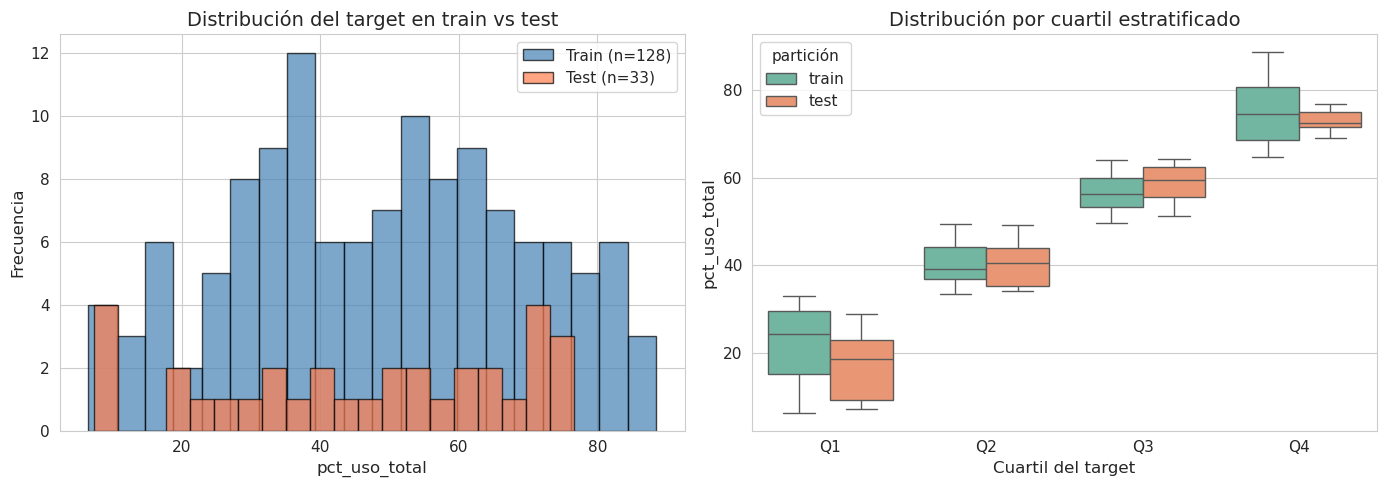

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma comparativo
axes[0].hist(y_train, bins=20, alpha=0.7, label=f'Train (n={len(y_train)})', color='steelblue', edgecolor='black')
axes[0].hist(y_test,  bins=20, alpha=0.7, label=f'Test (n={len(y_test)})',   color='coral',     edgecolor='black')
axes[0].set_xlabel('pct_uso_total')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del target en train vs test')
axes[0].legend()

# Boxplot por cuartil estratificado
data_box = pd.DataFrame({
    'pct_uso_total': pd.concat([y_train, y_test], ignore_index=True),
    'partición':     ['train'] * len(y_train) + ['test'] * len(y_test),
    'cuartil':       list(estratos_train) + list(estratos_test),
})
sns.boxplot(
    data=data_box, x='cuartil', y='pct_uso_total', hue='partición',
    ax=axes[1], palette='Set2', order=['Q1', 'Q2', 'Q3', 'Q4'],
)
axes[1].set_title('Distribución por cuartil estratificado')
axes[1].set_xlabel('Cuartil del target')
axes[1].set_ylabel('pct_uso_total')

plt.tight_layout()
plt.show()

---
### 5. Definición de Modelos

#### 5.1 Tabla de modelos y justificación

Se entrenan **cinco modelos** que cubren tres familias de algoritmos. Esto permite una comparación más enriquecedora.

| # | Modelo | Familia | Por qué se incluye |
|---|---|---|---|
| 1 | `LinearRegression` | Lineal sin regularización | Baseline interpretable; referencia de varianza explicada por una relación lineal. |
| 2 | `Ridge` (α=1.0) | Lineal regularizado L2 | Robusto a multicolinearidad (los seis lags son altamente correlacionados entre sí). |
| 3 | `KNeighborsRegressor` (k=5) | No paramétrico basado en distancia | Captura patrones locales; útil para contrastar la suavidad asumida por los modelos lineales. |
| 4 | `DecisionTreeRegressor` (por defecto) | Árbol único | No-lineal, interpretable individualmente; sirve como base para ensembles. |
| 5 | `RandomForestRegressor` (n=100) | Ensemble por bagging | Modelo competitivo de "caja gris"; provee importancia de features y suele resistir overfit en datos tabulares pequeños. |

**Decisión clave sobre el escalado**: los modelos lineales y de distancia se envuelven en `Pipeline([StandardScaler(), modelo])`. Esto garantiza que el escalado se ajuste **solo con los datos de entrenamiento dentro del split**, sin filtrar estadísticas del test (lo cual sí ocurriría si usáramos columnas estandarizadas precalculadas sobre las 175 filas completas). Los modelos basados en árboles son insensibles a la escala y se entrenan directamente.

In [ ]:
modelos = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=1.0)),
    ]),
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsRegressor(n_neighbors=5)),
    ]),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
}

print(f'Total de modelos definidos: {len(modelos)}')
print(f'{"Modelo":<22} | Familia                        | Escalado interno')
print(f'{"─" * 22}─┼─{"─" * 30}─┼─{"─" * 18}')
print(f'{"Linear Regression":<22} | Lineal sin regularización      | Sí (Pipeline)')
print(f'{"Ridge":<22} | Lineal regularizado L2         | Sí (Pipeline)')
print(f'{"KNN (k=5)":<22} | Basado en distancia            | Sí (Pipeline)')
print(f'{"Decision Tree":<22} | Árbol único                    | No requerido')
print(f'{"Random Forest":<22} | Ensemble (bagging)             | No requerido')

Total de modelos definidos: 5
Modelo                 | Familia                        | Escalado interno
───────────────────────┼────────────────────────────────┼───────────────────
Linear Regression      | Lineal sin regularización      | Sí (Pipeline)
Ridge                  | Lineal regularizado L2         | Sí (Pipeline)
KNN (k=5)              | Basado en distancia            | Sí (Pipeline)
Decision Tree          | Árbol único                    | No requerido
Random Forest          | Ensemble (bagging)             | No requerido


---
### 6. Entrenamiento y Evaluación

#### 6.1 Función auxiliar de evaluación

Para evitar repetir lógica, se define una función que entrena un modelo y devuelve un diccionario con las cuatro métricas en train y test:

In [ ]:
def evaluar_modelo(modelo, X_train, X_test, y_train, y_test):
    """Entrena el modelo y devuelve métricas en train/test y las predicciones."""
    modelo.fit(X_train, y_train)
    y_pred_train = modelo.predict(X_train)
    y_pred_test  = modelo.predict(X_test)

    metricas = {
        'MAE_train':  mean_absolute_error(y_train, y_pred_train),
        'MAE_test':   mean_absolute_error(y_test,  y_pred_test),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'R2_train':   r2_score(y_train, y_pred_train),
        'R2_test':    r2_score(y_test,  y_pred_test),
        'MAPE_train': mean_absolute_percentage_error(y_train, y_pred_train) * 100,
        'MAPE_test':  mean_absolute_percentage_error(y_test,  y_pred_test)  * 100,
    }
    return metricas, y_pred_train, y_pred_test

#### 6.2 Entrenamiento de los cinco modelos

In [ ]:
resultados = {}
predicciones = {}

print('Entrenando modelos:')
print('─' * 50)
for nombre, mdl in modelos.items():
    metricas, y_pred_train, y_pred_test = evaluar_modelo(mdl, X_train, X_test, y_train, y_test)
    resultados[nombre] = metricas
    predicciones[nombre] = {'train': y_pred_train, 'test': y_pred_test}
    print(f'  {nombre:<22} OK   (R² test = {metricas["R2_test"]:.4f}, RMSE test = {metricas["RMSE_test"]:.3f})')

print('─' * 50)
print(f'Entrenamiento completo: {len(resultados)} modelos.')

Entrenando modelos:
──────────────────────────────────────────────────
  Linear Regression      OK   (R² test = 0.9916, RMSE test = 2.008)
  Ridge                  OK   (R² test = 0.9919, RMSE test = 1.972)
  KNN (k=5)              OK   (R² test = 0.8882, RMSE test = 7.333)
  Decision Tree          OK   (R² test = 0.9821, RMSE test = 2.930)
  Random Forest          OK   (R² test = 0.9889, RMSE test = 2.307)
──────────────────────────────────────────────────
Entrenamiento completo: 5 modelos.


---
### 7. Comparación de Modelos

#### 7.1 Tabla comparativa de métricas

In [ ]:
tabla_resultados = pd.DataFrame(resultados).T.round(4)
tabla_resultados = tabla_resultados[[
    'MAE_train', 'MAE_test',
    'RMSE_train', 'RMSE_test',
    'R2_train',   'R2_test',
    'MAPE_train', 'MAPE_test',
]]
tabla_resultados = tabla_resultados.sort_values('R2_test', ascending=False)

print('Tabla comparativa de métricas (ordenada por R² en test, descendente):')
display(tabla_resultados)

Tabla comparativa de métricas (ordenada por R² en test, descendente):


,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,MAPE_train,MAPE_test
Ridge,1.1252,1.4910,1.5881,1.9720,0.9941,0.9919,2.9743,3.5845
Linear Regression,1.0838,1.5162,1.5058,2.0079,0.9947,0.9916,2.8252,3.5153
Random Forest,0.6677,1.8934,0.8524,2.3075,0.9983,0.9889,1.7248,5.2955
Decision Tree,0.0000,2.4657,0.0000,2.9303,1.0000,0.9821,0.0000,7.0096
KNN (k=5),3.4331,6.0474,5.2250,7.3329,0.9366,0.8882,9.8413,16.3205


Cuatro de los cinco modelos superan R² = 0.98 en test, lo que confirma que el problema es altamente predecible cuando se dispone del lag del target. El ranking se separa en tres grupos:

- **Cabeza muy ajustada**: Ridge (R² = 0.9919) y Linear Regression (R² = 0.9916) producen métricas casi idénticas. Esto indica que el problema es esencialmente lineal y que la regularización L2 aporta solo una mejora marginal.
- **Tier intermedio**: Random Forest (R² = 0.9889) y Decision Tree (R² = 0.9821). El árbol único ya muestra señal clara de overfit (R² train = 1.0000, MAE train = 0.0).
- **Cola**: KNN (R² = 0.8882) queda notablemente atrás, con un MAE en test de 6.05 pts. porcentuales (cuatro veces el de los mejores modelos). La métrica basada en distancia sufre con el espacio de 22 dimensiones y con la presencia de 13 dummies binarias.

#### 7.2 Visualización comparativa de métricas

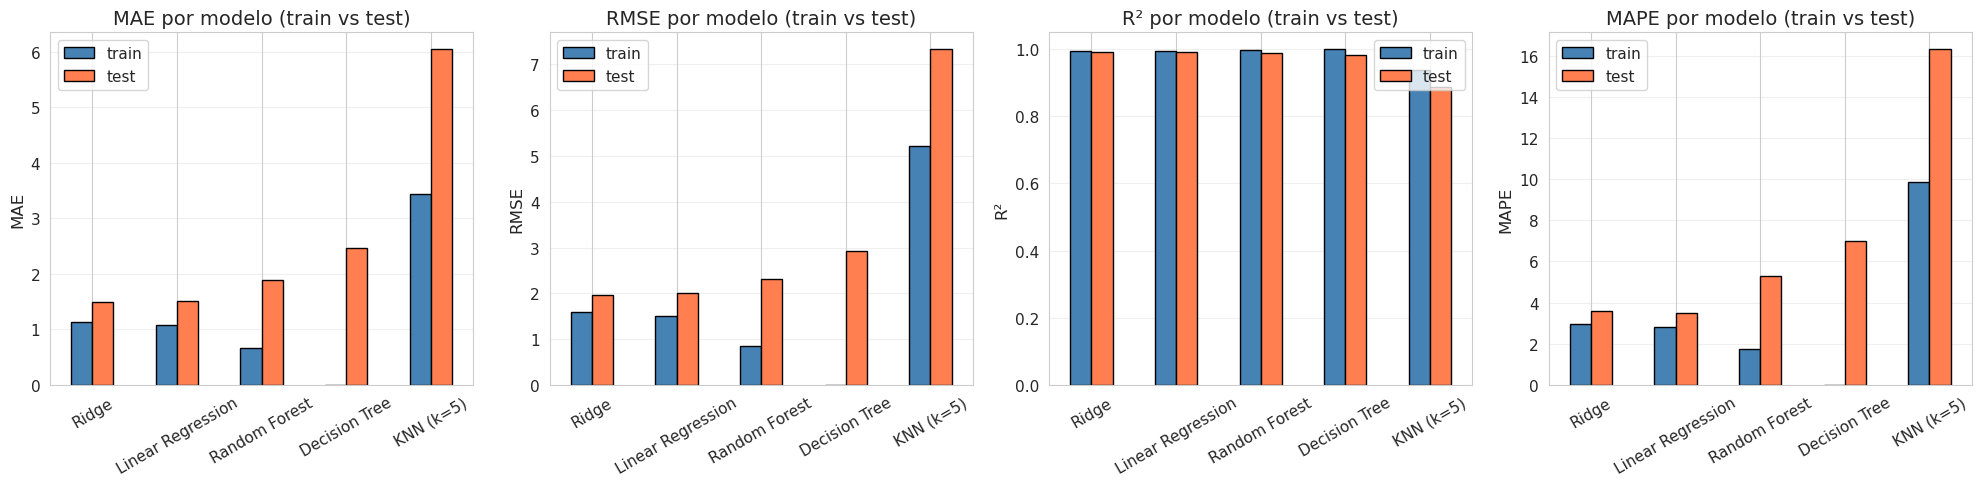

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metricas_visualizar = ['MAE', 'RMSE', 'R2', 'MAPE']

for ax, met in zip(axes, metricas_visualizar):
    plot_df = tabla_resultados[[f'{met}_train', f'{met}_test']].copy()
    plot_df.columns = ['train', 'test']
    plot_df.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='black')
    titulo = met if met != 'R2' else 'R²'
    ax.set_title(f'{titulo} por modelo (train vs test)')
    ax.set_ylabel(titulo)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='best')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### 7.3 Análisis de overfit (gap entre train y test)

Un gap grande entre la métrica en train y test sugiere que el modelo memoriza el conjunto de entrenamiento sin generalizar. Se calculan diferencias absolutas para MAE/RMSE y la caída de R² (train − test):

In [ ]:
gap = pd.DataFrame({
    'gap_MAE (test-train)':   (tabla_resultados['MAE_test']  - tabla_resultados['MAE_train']).round(4),
    'gap_RMSE (test-train)':  (tabla_resultados['RMSE_test'] - tabla_resultados['RMSE_train']).round(4),
    'gap_R² (train-test)':    (tabla_resultados['R2_train']  - tabla_resultados['R2_test']).round(4),
})
gap = gap.sort_values('gap_R² (train-test)')

print('Gap entre train y test (un gap grande indica overfit):')
display(gap)

Gap entre train y test (un gap grande indica overfit):


,gap_MAE (test-train),gap_RMSE (test-train),gap_R² (train-test)
Ridge,0.3658,0.3839,0.0022
Linear Regression,0.4324,0.5021,0.0031
Random Forest,1.2257,1.4551,0.0094
Decision Tree,2.4657,2.9303,0.0179
KNN (k=5),2.6143,2.1079,0.0484


**Lectura del gap**:

- **Ridge** y **Linear Regression** muestran los gaps más bajos (R² 0.0022 y 0.0031), confirmando una generalización sólida.
- **Random Forest** mantiene un gap moderado (0.0094) (esperado para un ensemble con 100 árboles sin restricción de profundidad).
- **Decision Tree** evidencia overfit claro: R² train = 1.0000 (memoriza perfectamente el train) frente a R² test = 0.9821, con un MAE en train de 0.0. Es el comportamiento típico de un árbol sin regularización.
- **KNN** tiene el gap más grande en R² (0.0484), pero esto se da en un nivel de rendimiento inferior; no se trata de overfit clásico sino de un modelo intrínsecamente menos adecuado para este problema.